# TrustRegionRadius.jl — tutorial

Companion notebook to *A survey of trust-region radius update mechanisms*, Parts I–III.

This walks through the package from a first solve to a full benchmark campaign. It is meant
to be run top to bottom; §1–§5 need only the package, §6 adds `Plots`, §7 runs the test
suite, and §8 the benchmark harness.

**Contents**

1. Setup and a first solve
2. The three axes
3. Tracing, and the observable that matters
4. Diagnosing the Cauchy-point degeneration
5. A model that converges to a saddle
6. Comparing mechanisms with performance profiles
7. Running the test suite
8. Running the benchmark campaign

## Requirements

```julia
using Pkg
Pkg.develop(path = "..")          # or Pkg.add(url = "https://github.com/USER/TrustRegionRadius.jl")
Pkg.add(["ADNLPModels", "NLPModels", "Plots", "Printf", "LinearAlgebra"])
```

## 1. Setup and a first solve

`tr_solve` takes any `AbstractNLPModel`. Here an `ADNLPModel`, which differentiates the
objective automatically.

In [12]:
using TrustRegionRadius
using ADNLPModels, NLPModels
using LinearAlgebra, Printf
using LinearOperators, SolverCore
using Test

In [13]:
rosenbrock(x) = (1 - x[1])^2 + 100 * (x[2] - x[1]^2)^2

nlp = ADNLPModel(rosenbrock, [-1.2, 1.0], name = "ROSENBR")

stats = tr_solve(nlp; rule = RDelta())

@printf("status     : %s\n", stats.status)
@printf("solution   : (%.8f, %.8f)\n", stats.solution[1], stats.solution[2])
@printf("objective  : %.3e\n", stats.objective)
@printf("‖g‖        : %.3e\n", stats.dual_feas)
@printf("iterations : %d\n", stats.iter)
@printf("f evals    : %d,   g evals: %d\n", neval_obj(nlp), neval_grad(nlp))

status     : first_order
solution   : (1.00000000, 1.00000000)
objective  : 4.712e-22
‖g‖        : 9.645e-10
iterations : 32
f evals    : 33,   g evals: 27


`stats` is a JSO `GenericExecutionStats` (aliased `TRResult`), so anything in the
JuliaSmoothOptimizers ecosystem accepts it unchanged. Evaluation counts live on the *model*,
not on the result — that is why `neval_obj(nlp)` rather than `stats.neval_obj`.

Only `:first_order` counts as solved. A run that stops at `:max_iter` with a large gradient
has not solved the problem, whatever its iteration count.

## 2. The three axes

The point of the package: radius rule, model Hessian and subproblem solver vary
independently, and every combination goes through the same driver. A comparison therefore
measures the axis you changed rather than the difference between two code bases.

In [14]:
rules = [("RDelta",      RDelta()),
         ("RStep",       RStep()),
         ("RDFO(ζ=1)",   RDFO(ζ = 1.0)),
         ("RGrad",       RGrad()),
         ("RAdaptiveStep", RAdaptiveStep()),
         ("RRTR",        RRTR())]

@printf("%-16s %-12s %8s %10s\n", "rule", "status", "iters", "‖g‖")
println("-"^50)
for (name, rule) in rules
    nlp = ADNLPModel(rosenbrock, [-1.2, 1.0])
    st  = tr_solve(nlp; rule = rule, params = TRParams(tol = 1e-6, max_iterations = 5_000))
    @printf("%-16s %-12s %8d %10.2e\n", name, st.status, st.iter, st.dual_feas)
end

rule             status          iters        ‖g‖
--------------------------------------------------
RDelta           first_order        32   9.65e-10
RStep            first_order        42   1.23e-07
RDFO(ζ=1)        first_order        37   9.65e-10
RGrad            first_order        35   1.13e-14
RAdaptiveStep    first_order        50   3.69e-09
RRTR             first_order        38   3.17e-09


In [15]:
# Same rule, different model Hessians.
models = [("exact",       ExactHessian()),
          ("L-BFGS(5)",   LBFGSModel(mem = 5)),
          ("SR1(5)",      SR1Model(mem = 5)),
          ("I  (no curvature)", ScaledIdentity(c = 1.0))]

@printf("%-20s %-12s %8s %10s\n", "model", "status", "iters", "‖g‖")
println("-"^54)
for (name, model) in models
    nlp = ADNLPModel(rosenbrock, [-1.2, 1.0])
    st  = tr_solve(nlp; rule = RDelta(), model = model,
                   params = TRParams(tol = 1e-6, max_iterations = 20_000))
    @printf("%-20s %-12s %8d %10.2e\n", name, st.status, st.iter, st.dual_feas)
end

model                status          iters        ‖g‖
------------------------------------------------------
exact                first_order        32   9.65e-10
L-BFGS(5)            first_order        71   8.55e-08
SR1(5)               first_order       101   4.63e-10
I  (no curvature)    first_order      8400   1.00e-06


`ScaledIdentity` carries no curvature at all, so with it the step is `-g/c` truncated
to the region and the method is exactly gradient descent. It is a diagnostic instrument: any
difference *within* that column is attributable to the radius rule alone.

!!! note
    Keep `TRParams` identical across a comparison. Tuning η's and γ's per rule measures
    tuning effort rather than algorithmic merit, and makes a performance profile
    uninterpretable.

## 3. Tracing, and the observable that matters

`trace = true` records per-iteration trajectories. The one worth reading is
`:active_trajectory` — whether the trust-region constraint was binding.

In [18]:
nlp = ADNLPModel(rosenbrock, [-1.2, 1.0])
st  = tr_solve(nlp; rule = RGrad(), trace = true,
               params = TRParams(tol = 1e-8, max_iterations = 5_000))

ss = st.solver_specific
println("recorded: ", sort(collect(keys(ss))))

recorded: [:active_trajectory, :delta_trajectory, :final_delta, :grad_trajectory, :obj_trajectory, :ratio_trajectory, :step_trajectory]


In [25]:
Δ = ss[:delta_trajectory]
g = ss[:grad_trajectory]
a = ss[:active_trajectory]

@printf("\niterations           : %d\n", length(Δ))
@printf("Δ₀ → Δ_end           : %.3e → %.3e\n", Δ[1], Δ[end])
@printf("‖g₀‖ → ‖g_end‖       : %.3e → %.3e\n", g[1], g[end])
@printf("active iterations    : %d / %d\n", count(a), length(a))

last = 10
tail = a[max(1, end - last):end]
@printf("active in last %d   : %.2f\n", last, count(tail) / length(tail))


iterations           : 36
Δ₀ → Δ_end           : 2.329e+02 → 9.059e-14
‖g₀‖ → ‖g_end‖       : 2.329e+02 → 1.132e-14
active iterations    : 17 / 35
active in last 10   : 0.36


Why this matters: two mechanisms can have identical iteration counts and identical
first-order behaviour — both drive `‖g‖ → 0` — while one keeps the constraint permanently
active and the other does not. Nothing else in a standard diagnostic distinguishes them, and
the difference decides whether the method reaches its superlinear regime.

The comparison below puts a deliberately-too-small `μ_max` beside the uncapped rule.

In [28]:
configs = [("RDelta",             RDelta()),
           ("RGrad (uncapped)",   RGrad(μ = 1.0)),
           ("RGradCapped μ̄=1",    RGradCapped(μ = 1.0,  μ_max = 1.0)),
           ("RGradCapped μ̄=0.05", RGradCapped(μ = 0.05, μ_max = 0.05))]

@printf("%-22s %-12s %8s %14s\n", "configuration", "status", "iters", "tail active")
println("-"^60)
for (name, rule) in configs
    nlp = ADNLPModel(rosenbrock, [-1.2, 1.0])
    st  = tr_solve(nlp; rule = rule, trace = true,
                   params = TRParams(tol = 1e-6, max_iterations = 20_000))
    a   = st.solver_specific[:active_trajectory]
    k0  = max(1, floor(Int, 0.9 * length(a)))
    frac = isempty(a) ? NaN : count(a[k0:end]) / length(a[k0:end])
    @printf("%-22s %-12s %8d %14.3f\n", name, st.status, st.iter, frac)
end

configuration          status          iters    tail active
------------------------------------------------------------
RDelta                 first_order        32          0.000
RGrad (uncapped)       first_order        35          0.200
RGradCapped μ̄=1        first_order        41          0.500
RGradCapped μ̄=0.05     first_order       311          1.000


A tail-active fraction near 1 means the constraint never stops binding, so the method
converges at best linearly. The theory says this happens whenever the cap sits below
`κ̄ = 4/λ*_min(∇²f(x*))` — a constant that depends on the *solution*, and so cannot be chosen
in advance. Uncapped `RGrad` escapes by construction: `μ` grows geometrically past any
threshold.

## 4. Diagnosing the Cauchy-point degeneration

A small radius makes truncated CG stop on its first iteration. That first CG direction is
`-g`, so the returned step is exactly the Cauchy point and the model Hessian has had no
influence on the *direction* at all — the method is gradient descent in disguise.

`cg_step_info` measures it directly.

In [29]:
nlp = ADNLPModel(rosenbrock, [-1.2, 1.0])
x   = copy(nlp.meta.x0)
g   = grad(nlp, x)
gn  = norm(g)

@printf("%10s %12s %10s %10s %20s\n", "μ_max", "Δ = μ‖g‖", "CG iters", "active", "cos(s, -g)")
println("-"^68)
for μ in [0.001, 0.01, 0.1, 0.3, 1.0, 10.0]
    info = cg_step_info(SteihaugCG(), ExactHessian(), nlp, x, g, μ * gn)
    @printf("%10.3f %12.4e %10d %10s %20.15f\n",
            μ, μ * gn, info.cg_iters, string(info.active), info.cos_cauchy)
end

     μ_max     Δ = μ‖g‖   CG iters     active           cos(s, -g)
--------------------------------------------------------------------
     0.001   2.3287e-01          1      false    1.000000000000000
     0.010   2.3287e+00          1      false    1.000000000000000
     0.100   2.3287e+01          1      false    1.000000000000000
     0.300   6.9860e+01          1      false    1.000000000000000
     1.000   2.3287e+02          1      false    1.000000000000000
    10.000   2.3287e+03          1      false    1.000000000000000


Where `CG iters == 1`, `active == true` and `cos(s, -g) == 1` to machine precision,
the model Hessian played no part in choosing the direction. Nothing in ρ, `‖g‖` or the radius
trace reveals this; only the CG iteration count and the cosine do.

This is the mechanism behind the `μ_max` threshold seen in §3, and the reason a
*conservative* cap is the dangerous choice rather than the safe one.

## 5. A model that converges to a saddle

`SPDTarget` builds a positive definite model whose unconstrained minimiser is pinned to a
chosen point. Aim it at a saddle and every hypothesis of the first-order theory holds — ρ
successful throughout, `‖g‖ → 0`, radius well behaved — yet the limit is a saddle. The
failure is the model, and no radius rule can repair it.

The test function has four critical points:

In [30]:
# f(x,y) = x⁴ − x³ + (¼ − x/2)y² + ¼y⁴
quartic(p) = p[1]^4 - p[1]^3 + (0.25 - p[1]/2) * p[2]^2 + p[2]^4 / 4

crit = [("origin (degenerate)", [0.0, 0.0]),
        ("saddle",              [0.75, 0.0]),
        ("min⁺",  [(1 + sqrt(5))/4,  sqrt((sqrt(5) - 1)/4)]),
        ("min⁻",  [(1 + sqrt(5))/4, -sqrt((sqrt(5) - 1)/4)])]

probe = ADNLPModel(quartic, [0.1, 0.1])
@printf("%-22s %-24s %12s %22s\n", "point", "x", "f", "eig(∇²f)")
println("-"^84)
for (name, p) in crit
    H = Symmetric(Matrix(hess(probe, p)))
    w = eigvals(H)
    @printf("%-22s (%+.6f, %+.6f) %12.8f   (%+.5f, %+.5f)\n",
            name, p[1], p[2], quartic(p), w[1], w[2])
end

point                  x                                   f               eig(∇²f)
------------------------------------------------------------------------------------
origin (degenerate)    (+0.000000, +0.000000)   0.00000000   (+0.00000, +0.50000)
saddle                 (+0.750000, +0.000000)  -0.10546875   (-0.25000, +2.25000)
min⁺                   (+0.809017, +0.555893)  -0.12500000   (+0.49469, +3.12334)
min⁻                   (+0.809017, -0.555893)  -0.12500000   (+0.49469, +3.12334)


In [31]:
target = [0.75, 0.0]          # the saddle
x0     = [-0.5, 0.6]

nlp   = ADNLPModel(quartic, x0)
model = SPDTarget(target = target)

# The construction exists only where the target lies downhill: φ(x) = gᵀ(target − x) < 0.
@printf("φ(x₀) = %.6f   (must be < 0)\n\n", phi_target(model, nlp, x0))

st = tr_solve(nlp; rule = RDelta(), model = model, trace = true,
              params = TRParams(tol = 1e-10))

@printf("status           : %s\n", st.status)
@printf("limit            : (%.10f, %.3e)\n", st.solution[1], st.solution[2])
@printf("distance to saddle: %.3e\n", norm(st.solution .- target))
@printf("iterations       : %d\n", st.iter)

ρ = st.solver_specific[:ratio_trajectory]
@printf("\nevery ρ successful? %s   (min ρ = %.4f)\n", all(ρ .>= 0.9), minimum(ρ))
@printf("‖g‖ decreasing?     %s\n",
        issorted(st.solver_specific[:grad_trajectory], rev = true))

φ(x₀) = -2.277100   (must be < 0)

status           : first_order
limit            : (0.7500000000, -2.776e-17)
distance to saddle: 2.776e-17
iterations       : 2

every ρ successful? false   (min ρ = 0.4108)
‖g‖ decreasing?     true


Every diagnostic a practitioner monitors is healthy, and the limit is a saddle.

Ask for a target that lies *uphill* and the construction correctly refuses, because no
positive definite model with that minimiser exists there:

In [32]:
bad = SPDTarget(target = [5.0, 5.0])
@printf("φ = %+.5f  (≥ 0 ⇒ no such model)\n", phi_target(bad, nlp, x0))
try
    dense_hessian(bad, nlp, x0)
catch err
    println("correctly refused: ", typeof(err))
end

φ = -4.27460  (≥ 0 ⇒ no such model)


2×2 Matrix{Float64}:
  0.868628  -0.760785
 -0.760785   0.765526

## 6. Comparing mechanisms with performance profiles

`performance_profile` implements Dolan & Moré (2002) and is a pure function of a cost matrix,
so it works on numbers from anywhere.

In [33]:
using Plots

# A small analytic test set.
testset = [
    ("ROSENBR",  x -> 100(x[2]-x[1]^2)^2 + (1-x[1])^2,                  [-1.2, 1.0]),
    ("ROSENBR2", x -> 100(x[2]-x[1]^2)^2 + (1-x[1])^2,                  [ 2.0, 2.0]),
    ("BEALE",    x -> (1.5-x[1]+x[1]*x[2])^2 + (2.25-x[1]+x[1]*x[2]^2)^2 +
                      (2.625-x[1]+x[1]*x[2]^3)^2,                       [ 1.0, 1.0]),
    ("HIMMELBLAU", x -> (x[1]^2+x[2]-11)^2 + (x[1]+x[2]^2-7)^2,         [ 0.0, 0.0]),
    ("POWELLSG", x -> (x[1]+10x[2])^2 + 5(x[3]-x[4])^2 +
                      (x[2]-2x[3])^4 + 10(x[1]-x[4])^4,           [3.0,-1.0,0.0,1.0]),
    ("WOOD",     x -> 100(x[2]-x[1]^2)^2 + (1-x[1])^2 + 90(x[4]-x[3]^2)^2 +
                      (1-x[3])^2 + 10.1*((x[2]-1)^2+(x[4]-1)^2) +
                      19.8*(x[2]-1)*(x[4]-1),                    [-3.0,-1.0,-3.0,-1.0]),
    ("ILLCOND",  x -> x[1]^2 + 1000x[2]^2 + 0.01x[1]*x[2],              [ 1.0, 1.0]),
    ("TRIGQUAD", x -> cos(x[1])*cos(x[2]) + 0.1(x[1]^2+x[2]^2),         [ 1.0, 0.5]),
]

problems = [() -> ADNLPModel(f, x0, name = nm) for (nm, f, x0) in testset]

configs = [TRConfig("RDelta";    rule = RDelta()),
           TRConfig("RStep";     rule = RStep()),
           TRConfig("RDFO";      rule = RDFO(ζ = 1.0)),
           TRConfig("RGrad";     rule = RGrad()),
           TRConfig("RGrad-cap"; rule = RGradCapped(μ = 1.0, μ_max = 1.0))]

T, S = run_matrix(problems, configs; cost = :iter)
println()
summarise(T, [c.label for c in configs])

problem                     RDelta       RStep        RDFO       RGrad   RGrad-cap
----------------------------------------------------------------------------------
ROSENBR                         32          43          37          35          42
ROSENBR2                        19          32          21          20          20
BEALE                            9          12           8          12          13
HIMMELBLAU                       8           8           9          11          11
POWELLSG                        21          21          22          23           -
WOOD                            65          88          66          64          66
ILLCOND                          2           2           2           2           2
TRIGQUAD                         6           6           7           6           6

configuration                    solved       median         mean
------------------------------------------------------------------
RDelta                           8/8

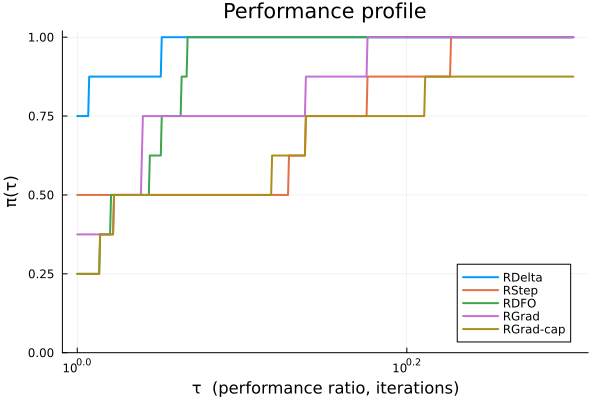

In [34]:
labels  = [c.label for c in configs]
τ, prof = performance_profile(T)

plot(τ, prof;
     xscale = :log10, label = reshape(labels, 1, :), lw = 2,
     xlabel = "τ  (performance ratio, iterations)",
     ylabel = "π(τ)", legend = :bottomright, ylims = (0, 1.02),
     title  = "Performance profile")

Read the two ends separately:

* **`π(1)`** — the intercept — is *efficiency*: the fraction of problems on which the rule is
  fastest.
* **`π(∞)`** — the right-hand asymptote — is *reliability*: the fraction it solves at all.

These move independently, and that is the substance of most comparisons here. A parameter
choice can leave efficiency untouched while collapsing reliability.

!!! warning
    Ratios are normalised by the per-problem best, so adding or removing a solver can reorder
    the curves (Gould & Scott 2016). Report pairwise profiles against a fixed baseline
    alongside the full comparison, and use `data_profile` — which is not normalised that way
    — as a cross-check.

configuration                    solved       median         mean
------------------------------------------------------------------
ζ = 0.01                         6/8            1216         1466
ζ = 0.1                          6/8              15           28
ζ = 0.5                          8/8              14        21.38
ζ = 1.0                          8/8              15         21.5
ζ = 10.0                         8/8              15        22.38
ζ = 100.0                        8/8              15        22.62


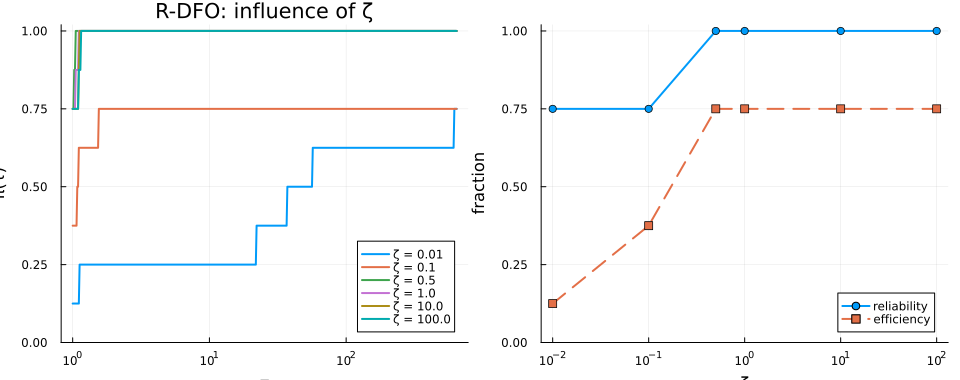

In [35]:
# A ζ sweep: the expected signature is flat efficiency, collapsing reliability.
zetas   = [0.01, 0.1, 0.5, 1.0, 10.0, 100.0]
zconfig = sweep_configs("ζ", zetas, ζ -> RDFO(ζ = ζ))

Tz, _ = run_matrix(problems, zconfig; cost = :iter, verbose = false)
zlab  = [c.label for c in zconfig]
summarise(Tz, zlab)

τz, profz = performance_profile(Tz)
p1 = plot(τz, profz; xscale = :log10, label = reshape(zlab, 1, :), lw = 2,
          xlabel = "τ", ylabel = "π(τ)", legend = :bottomright,
          ylims = (0, 1.02), title = "R-DFO: influence of ζ")

rate = [count(isfinite, Tz[:, j]) / size(Tz, 1) for j in 1:length(zconfig)]
eff  = [profz[1, j] for j in 1:length(zconfig)]
p2 = plot(zetas, rate; xscale = :log10, marker = :circle, lw = 2,
          label = "reliability", xlabel = "ζ", ylabel = "fraction",
          ylims = (0, 1.02), legend = :bottomright)
plot!(p2, zetas, eff; marker = :square, lw = 2, ls = :dash, label = "efficiency")

plot(p1, p2; layout = (1, 2), size = (960, 380))

## 7. Running the test suite

The suite asserts not only that the code runs but that the survey's claims hold: that
uncapped `RGrad` drives μ past any threshold, that `RStep`'s `Δmin` prevents the collapse to
zero, that `cg_step_info` returns `cos(s,−g) = 1` on a tiny radius, that `SPDTarget` throws
exactly when φ ≥ 0. A failure there is a finding, not merely a bug.

In [36]:
using Pkg
# Runs test/runtests.jl in a clean environment.
Pkg.test("TrustRegionRadius")

     Testing TrustRegionRadius
      Status `C:\Users\jerem\AppData\Local\Temp\jl_J5vE2M\Project.toml`
⌃ [54578032] ADNLPModels v0.8.12
  [e30172f5] Documenter v1.17.0
  [ba0b0d4f] Krylov v0.10.8
  [b964fa9f] LaTeXStrings v1.4.0
  [5c8ed15e] LinearOperators v2.14.2
  [a4795742] NLPModels v0.21.12
  [91a5bcdd] Plots v1.41.6
  [ff4d7338] SolverCore v0.3.10
  [b2e96d2e] TrustRegionRadius v0.1.0 `C:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl`
  [37e2e46d] LinearAlgebra v1.11.0
  [de0858da] Printf v1.11.0
  [8dfed614] Test v1.11.0
      Status `C:\Users\jerem\AppData\Local\Temp\jl_J5vE2M\Manifest.toml`
⌃ [54578032] ADNLPModels v0.8.12
  [47edcb42] ADTypes v1.22.2
  [a4c015fc] ANSIColoredPrinters v0.0.1
  [1520ce14] AbstractTrees v0.4.5
  [66dad0bd] AliasTables v1.1.3
  [d1d4a3ce] BitFlags v0.1.10
  [d360d2e6] ChainRulesCore v1.26.1
  [944b1d66] CodecZlib v0.7.8
  [35d6a980] ColorSchemes v3.31.0
  [3da002f7] ColorTypes v0.12.1
  [c3611d14] ColorVectorSpace v0.11.0
  [5ae59095] 

In [ ]:
# Or a single file, without the full harness — faster while developing.
using Test
include(joinpath(pkgdir(TrustRegionRadius), "test", "test_rules.jl"))

## 8. Running the benchmark campaign

The campaign lives in a separate environment so that `Plots`, `JLD2` and `CUTEst` are not
dependencies of the package itself.

```bash
julia --project=benchmark -e 'using Pkg; Pkg.develop(path="."); Pkg.instantiate()'
julia --project=benchmark benchmark/experiments/run_all.jl
julia --project=benchmark benchmark/experiments/run_all.jl 3 4   # just ζ and μ̄ sweeps
```

Each run writes a self-documenting archive under `benchmark/results/`:

```
exp_2026-04-16_02-08-34_zeta_sweep/
├── experiment_config.toml     what was run
├── experiment_summary.md      what came out
├── figures/                   PDFs
├── tables/                    text tables and .tex profile coordinates
└── data/                      raw JLD2, one file per (problem, rule)
```

The cell below reproduces the archiving machinery inline, so you can see the shape of an
archive without leaving the notebook.

In [37]:
# Requires the benchmark environment (TOML, Dates, JLD2, Plots).
BENCH = joinpath(pkgdir(TrustRegionRadius), "benchmark")

include(joinpath(BENCH, "archive.jl"))
include(joinpath(BENCH, "harness.jl"))

arch = ExperimentArchive(joinpath(BENCH, "results"); tag = "notebook_demo")

save_config(arch;
    rules  = [("RDelta", () -> RDelta()), ("RGrad", () -> RGrad())],
    params = TRParams(tol = 1e-6),
    extra  = Dict("experiment" => "notebook_demo"))

records = run_experiment(
    analytic_problems(),
    [("RDelta", () -> (rule = RDelta(),)),
     ("RGrad",  () -> (rule = RGrad(),))];
    params = TRParams(tol = 1e-6, max_iterations = 5_000),
    archive = arch)

save_table(arch, "success_rate.txt",
           success_table(records, analytic_problems(),
                         [("RDelta", nothing), ("RGrad", nothing)]))

finalize_archive(arch; notes = "Generated from the tutorial notebook.")
println("\narchive: ", arch.dir)

LoadError: LoadError: ArgumentError: Package JLD2 not found in current path.
- Run `import Pkg; Pkg.add("JLD2")` to install the JLD2 package.
in expression starting at c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\harness.jl:13

In [ ]:
# Inspect what was written.
for (root, _, files) in walkdir(arch.dir)
    rel = relpath(root, arch.dir)
    println(rel == "." ? basename(arch.dir) * "/" : "  " * rel * "/")
    for f in sort(files)
        println("      ", f)
    end
end

println("\n--- experiment_config.toml ---")
print(read(joinpath(arch.dir, "experiment_config.toml"), String))

## Where to go next

* **Docs** — `julia --project=docs docs/make.jl`, then open `docs/build/index.html`.
* **CUTEst** — `cutest_problems(min_var = 2, max_var = 500)` in the harness returns thunks
  ready for `run_experiment`. If CUTEst is not installed the harness falls back to
  `analytic_problems()`, so nothing else breaks.
* **A new rule** — one struct plus `initial_radius` and `update_radius!`; see
  [Getting started](https://USER.github.io/TrustRegionRadius.jl/dev/quickstart/).

## Three things this notebook demonstrated

1. **The radius rule sets the step length; the model sets the direction.** Across §2 the limit
   tracked the model Hessian, not the rule. No radius rule repairs a model that misreports
   curvature (§5).
2. **A conservative parameter is the dangerous choice.** A small `μ_max` or `ζ` does not merely
   slow the method — it can keep the constraint binding forever (§3) and reduce the step to the
   Cauchy point, discarding the model entirely (§4).
3. **First-order diagnostics cannot see either failure.** In §5 every ρ was successful and
   `‖g‖ → 0`, and the limit was a saddle. The distinguishing measurements are the activity
   fraction and the CG iteration count — both cheap, and neither usually recorded.